# Diabetes Prediction using Decision Tree Classifier
A basic machine learning project using Decision Tree on the Pima Indian Diabetes Dataset.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import joblib
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
df = pd.read_csv('../data/diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,131,72,15,202,38.8,0.119,55,0
1,14,113,69,30,3,17.3,0.330,29,0
2,10,147,77,12,27,40.1,0.142,55,1
3,7,50,91,18,18,41.7,0.080,31,0
4,6,128,87,21,21,29.9,0.491,64,0


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,7.747396,122.967448,69.195312,21.415365,75.341146,31.669401,0.473685,50.647135,0.308594
std,5.089934,31.537403,18.896296,14.503540,76.732511,7.134702,0.457027,17.041455,0.462214
min,0.000000,28.000000,11.000000,0.000000,0.000000,10.900000,0.080000,21.000000,0.000000
25%,3.000000,102.000000,57.000000,10.000000,21.000000,26.900000,0.131000,35.000000,0.000000
50%,7.000000,123.000000,69.000000,21.000000,52.000000,31.700000,0.319000,51.000000,0.000000
75%,12.000000,143.000000,82.000000,31.000000,103.250000,36.100000,0.639500,65.000000,1.000000
max,16.000000,199.000000,122.000000,70.000000,617.000000,54.700000,2.420000,80.000000,1.000000


## Step 3: Basic EDA

In [5]:
# Check missing values
print('Missing values:\n', df.isnull().sum())

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# Target class distribution
print('Target distribution:')
print(df['Outcome'].value_counts())
print(f"\nDiabetes rate: {df['Outcome'].mean()*100:.1f}%")

Target distribution:
Outcome
0    531
1    237
Name: count, dtype: int64

Diabetes rate: 30.9%


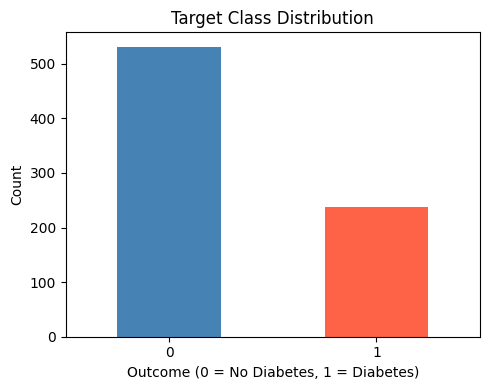

In [7]:
# Plot target distribution
plt.figure(figsize=(5, 4))
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Target Class Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

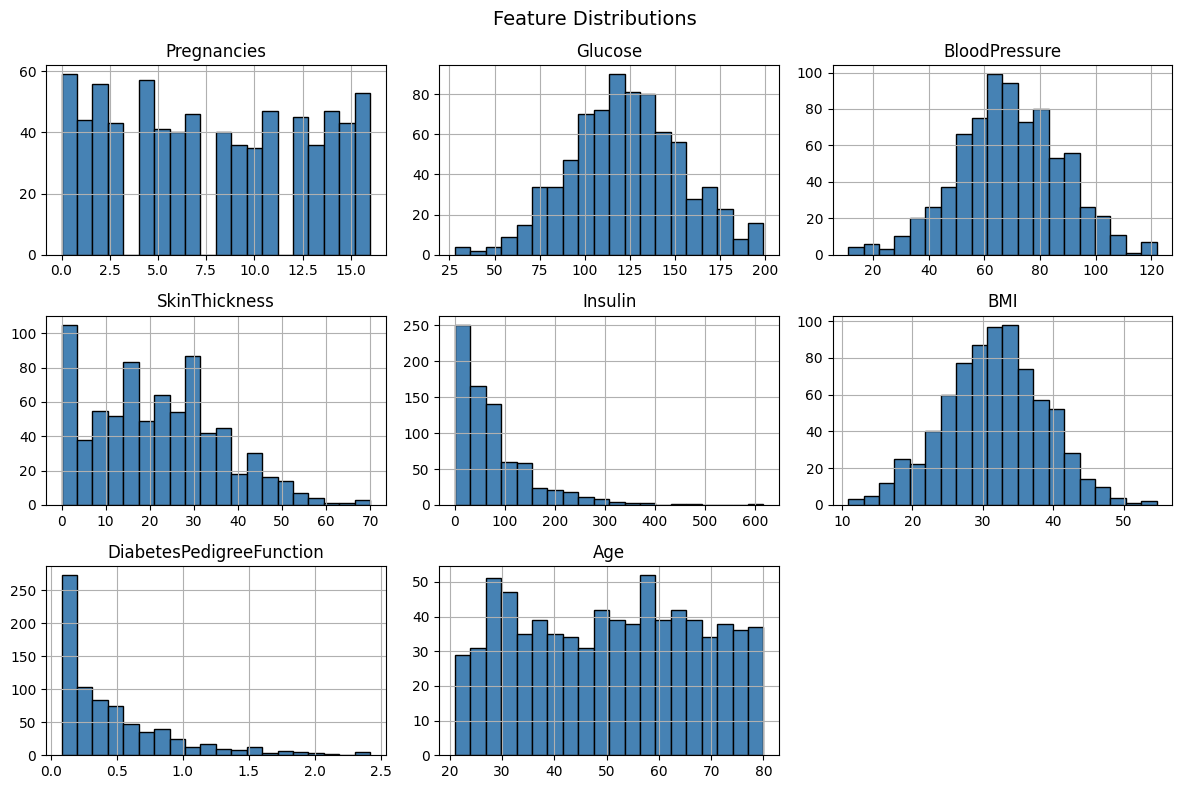

In [8]:
# Feature distributions
df.drop('Outcome', axis=1).hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

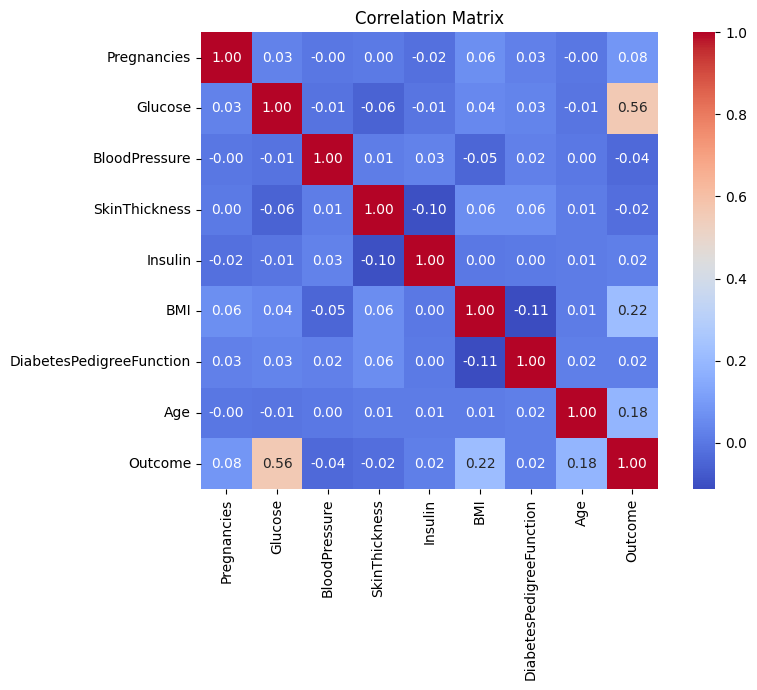

In [9]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [10]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [11]:
# Train-test split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 576
Testing samples: 192


## Step 5: Train Decision Tree Model

In [12]:
# Create and train a basic Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,          # limit tree depth to avoid overfitting
    min_samples_split=10, # minimum samples needed to split a node
    min_samples_leaf=5,   # minimum samples in each leaf
    random_state=42
)

dt_model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


## Step 6: Evaluate the Model

In [13]:
# Predictions
y_pred = dt_model.predict(X_test)
y_pred_train = dt_model.predict(X_train)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

print(f'Training Accuracy : {train_acc:.4f}')
print(f'Testing  Accuracy : {test_acc:.4f}')

Training Accuracy : 0.9271
Testing  Accuracy : 0.9115


In [14]:
# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.93      0.95      0.94       133
    Diabetes       0.88      0.83      0.85        59

    accuracy                           0.91       192
   macro avg       0.90      0.89      0.89       192
weighted avg       0.91      0.91      0.91       192



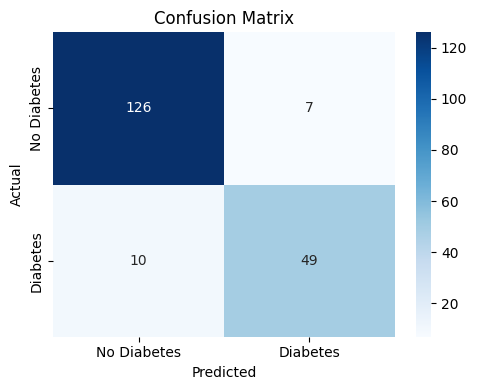

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 7: Feature Importance

                    Feature  Importance
1                   Glucose    0.713149
7                       Age    0.169752
5                       BMI    0.096855
4                   Insulin    0.020244
0               Pregnancies    0.000000
2             BloodPressure    0.000000
3             SkinThickness    0.000000
6  DiabetesPedigreeFunction    0.000000


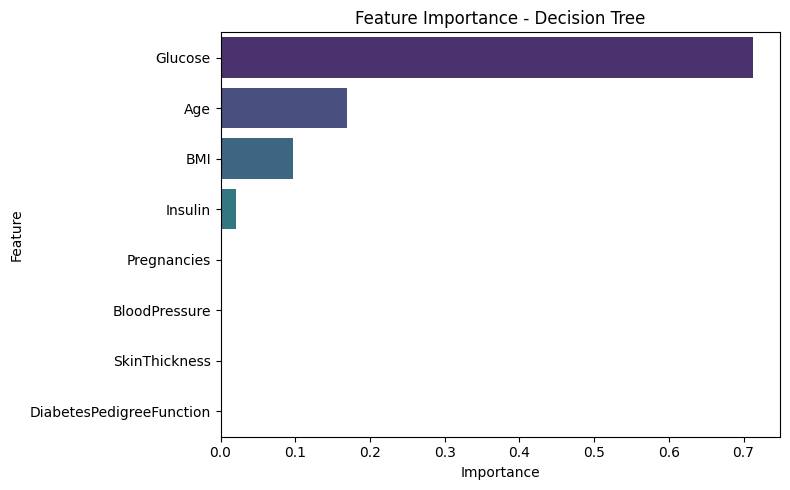

In [16]:
# Feature importance from Decision Tree
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()

## Step 8: Visualize the Decision Tree

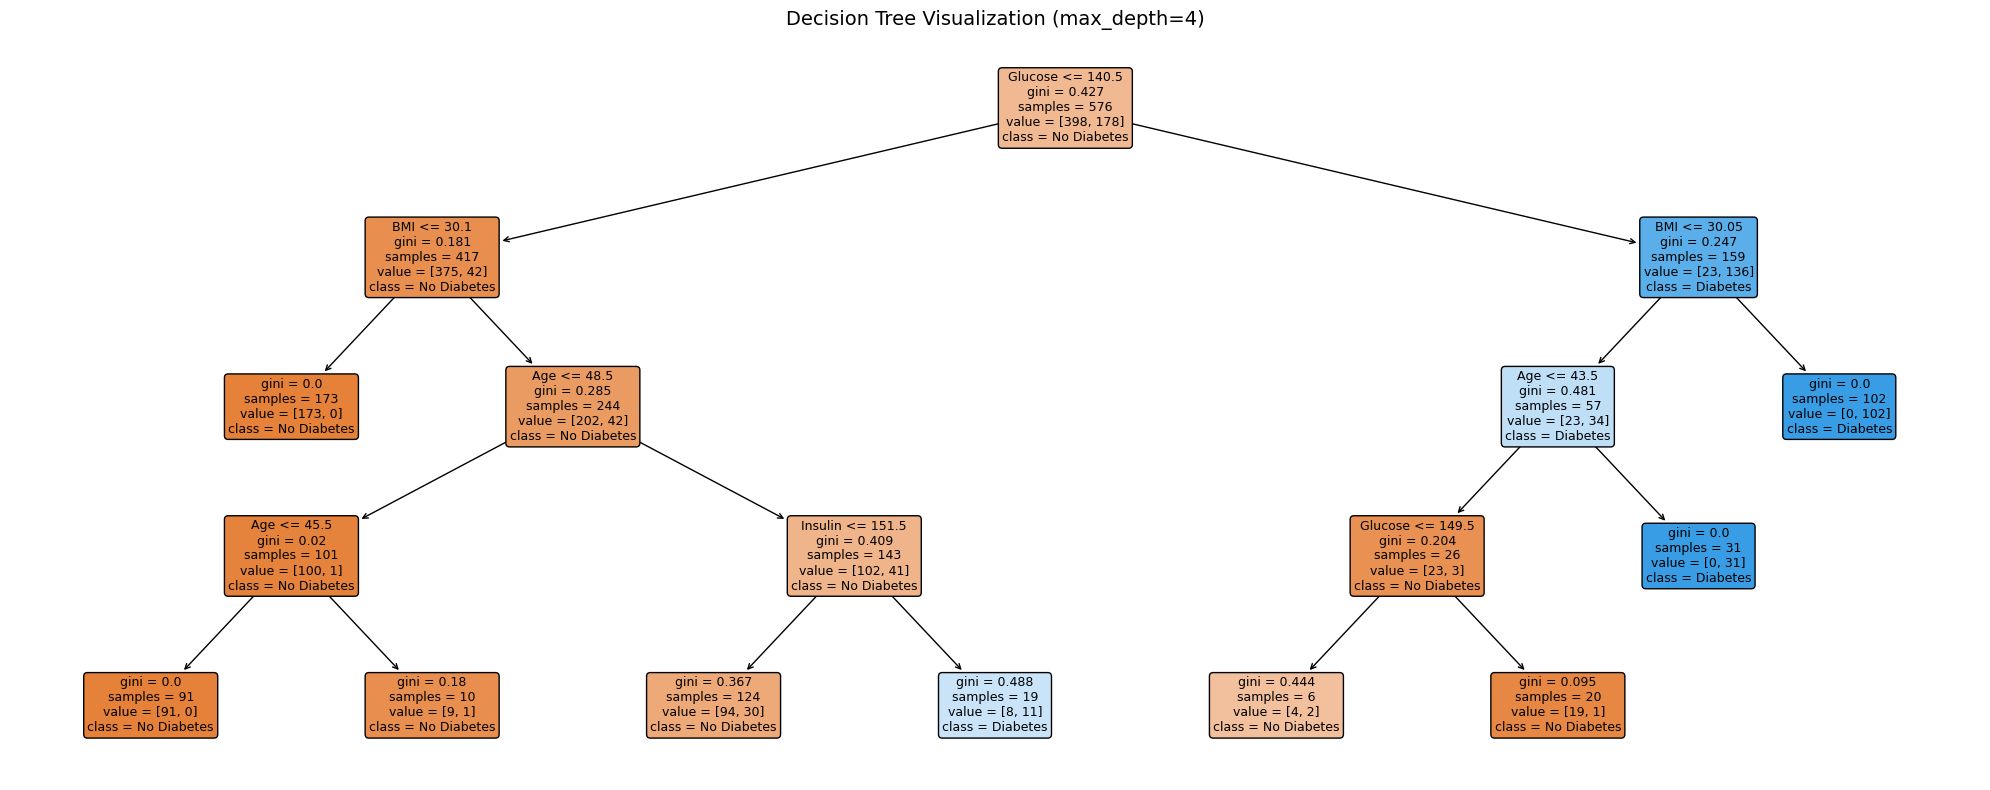

In [17]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree Visualization (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()

## Step 9: Save the Model

In [18]:
# Save model and feature names
joblib.dump(dt_model, '../models/decision_tree_model.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print('Model saved to models/decision_tree_model.pkl')

Model saved to models/decision_tree_model.pkl


## Step 10: Make a Sample Prediction

In [19]:
# Sample input: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DPF, Age]
sample = np.array([[3, 150, 75, 30, 100, 35.0, 0.600, 45]])

prediction = dt_model.predict(sample)[0]
probability = dt_model.predict_proba(sample)[0]

print(f'Prediction  : {"Diabetes" if prediction == 1 else "No Diabetes"}')
print(f'Confidence  : No Diabetes={probability[0]:.2%}, Diabetes={probability[1]:.2%}')

Prediction  : Diabetes
Confidence  : No Diabetes=0.00%, Diabetes=100.00%
